<a href="https://colab.research.google.com/github/mannatkalani/rnn_movie_recommendation/blob/main/RNN_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
df = pd.read_csv(
    "movie_reviews_sentiment.csv",
    engine="python",
    on_bad_lines="skip"
)

In [ ]:
df

,review,sentiment
0,"the central focus of michael winterbottom's "" ...",positive
1,"the "" fab 4 "" of ronald reagan high are four s...",negative
2,saving private ryan ( dreamworks ) running tim...,positive
3,there must be some unwritten rule that states ...,positive
4,"well , what are you going to expect ? it's a ...",negative
...,...,...
3466,"in the opening shot of midnight cowboy , we se...",positive
3467,"well , as i check my score card for what i've ...",negative
3468,"every year , hollywood crowns a new "" it boy ""...",positive
3469,we share the descent into darkness of a talent...,positive


In [ ]:
CSV_PATH = "movie_reviews_sentiment.csv"
VOCAB_SIZE = 10000
MAX_LEN = 300
EMBED_DIM = 64
BATCH_SIZE = 32
EPOCHS = 15

In [ ]:

df["label"] = (df["sentiment"] == "positive").astype(int)

print(df.shape)
print(df["label"].value_counts())
df.head()

(3471, 3)
label
1    1761
0    1710
Name: count, dtype: int64


,review,sentiment,label
0,"the central focus of michael winterbottom's "" ...",positive,1
1,"the "" fab 4 "" of ronald reagan high are four s...",negative,0
2,saving private ryan ( dreamworks ) running tim...,positive,1
3,there must be some unwritten rule that states ...,positive,1
4,"well , what are you going to expect ? it's a ...",negative,0


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_review"] = df["review"].apply(clean_text)
df[["review", "clean_review"]].head()

,review,clean_review
0,"the central focus of michael winterbottom's "" ...",the central focus of michael winterbottom's we...
1,"the "" fab 4 "" of ronald reagan high are four s...",the fab 4 of ronald reagan high are four stuck...
2,saving private ryan ( dreamworks ) running tim...,saving private ryan dreamworks running time 2 ...
3,there must be some unwritten rule that states ...,there must be some unwritten rule that states ...
4,"well , what are you going to expect ? it's a ...",well what are you going to expect it's a movie...


In [ ]:
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    df["clean_review"], df["label"], test_size=0.2,
    stratify=df["label"], random_state=SEED
)
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp, test_size=0.5,
    stratify=y_temp, random_state=SEED
)

print("Train:", len(X_train_text), "Val:", len(X_val_text), "Test:", len(X_test_text))

Train: 2776 Val: 347 Test: 348


In [ ]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)  # fit ONLY on train

def to_padded(text_series):
    seqs = tokenizer.texts_to_sequences(text_series)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train = to_padded(X_train_text)
X_val = to_padded(X_val_text)
X_test = to_padded(X_test_text)

y_train, y_val, y_test = y_train.values, y_val.values, y_test.values

X_train.shape, X_val.shape, X_test.shape

((2776, 300), (347, 300), (348, 300))

In [ ]:
model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.4),
    Bidirectional(LSTM(32)),
    Dropout(0.4),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid"),
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=2,
)

Epoch 1/15
87/87 - 79s - 907ms/step - accuracy: 0.5256 - loss: 0.6905 - val_accuracy: 0.5130 - val_loss: 0.6952
Epoch 2/15
87/87 - 54s - 617ms/step - accuracy: 0.8177 - loss: 0.4149 - val_accuracy: 0.8300 - val_loss: 0.4000
Epoch 3/15
87/87 - 51s - 584ms/step - accuracy: 0.9805 - loss: 0.0573 - val_accuracy: 0.8444 - val_loss: 0.5048
Epoch 4/15
87/87 - 52s - 595ms/step - accuracy: 0.9924 - loss: 0.0241 - val_accuracy: 0.8646 - val_loss: 0.5251
Epoch 5/15
87/87 - 80s - 924ms/step - accuracy: 0.9996 - loss: 0.0044 - val_accuracy: 0.8674 - val_loss: 0.6397


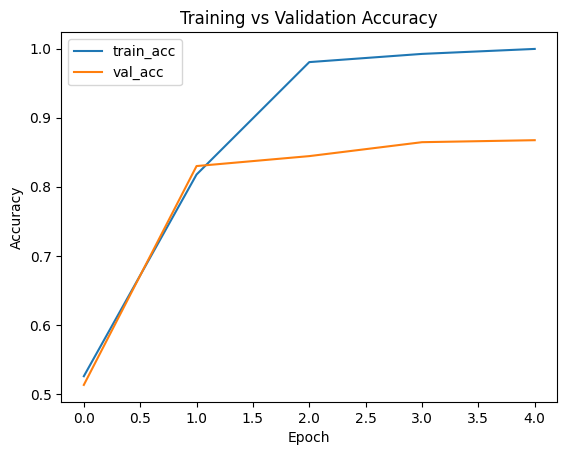

In [ ]:


plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Training vs Validation Accuracy")
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")

y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))
print(confusion_matrix(y_test, y_pred))

Test accuracy: 0.8621 | Test loss: 0.3394
              precision    recall  f1-score   support

    negative       0.89      0.82      0.85       171
    positive       0.84      0.90      0.87       177

    accuracy                           0.86       348
   macro avg       0.86      0.86      0.86       348
weighted avg       0.86      0.86      0.86       348

[[140  31]
 [ 17 160]]


In [ ]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    padded = to_padded(pd.Series([cleaned]))
    prob = model.predict(padded, verbose=0)[0][0]
    label = "positive" if prob > 0.5 else "negative"
    return label, float(prob)

predict_sentiment("This movie completely blew me away, incredible performances.")

('negative', 0.055709775537252426)